In [ ]:
# Импорт библиотек для анализа данных
import pandas as pd
import numpy as np
pd.options.mode.chained_assignment = None

# Импорт фильтрации предупреждений
from warnings import filterwarnings
filterwarnings("ignore", category=DeprecationWarning)
filterwarnings("ignore", category=FutureWarning)
filterwarnings("ignore", category=UserWarning)

# Импорт библиотек машинного обучения
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

# Импорт библиотек моделей машинного обучения
from sklearn.ensemble import GradientBoostingClassifier

# Импорт библиотек метрик для оценки моделей машинного обучения
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

# Импорт библиотеки для взаимодействия с AW
from aw_client import Session

In [ ]:
# Импортируем токен для подключения к AW
token = open('token.txt').read()
session = Session(token=token, aw_url='https://aw-demo.ru')

In [ ]:
# Загружаем датафрейм из AW для обучения модели машинного обучения
df = session.load_model(model_id = 11079) # указываем ID своей модели

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168378 entries, 0 to 168377
Data columns (total 18 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   donor_id                               168378 non-null  object 
 1   sum_amount                             168378 non-null  int64  
 2   mean_amount                            168378 non-null  float64
 3   count_transactions_completed           168378 non-null  int64  
 4   count_reccurent_transactions           168378 non-null  int64  
 5   mean_date_diff                         168378 non-null  int64  
 6   first_transaction_date                 168378 non-null  int64  
 7   last_transaction_date                  168378 non-null  int64  
 8   count_transactions_cancelled           168378 non-null  int64  
 9   cancelled_percentage                   168378 non-null  float64
 10  churn                                  168378 non-null  

In [5]:
df.head()

,donor_id,sum_amount,mean_amount,count_transactions_completed,count_reccurent_transactions,mean_date_diff,first_transaction_date,last_transaction_date,count_transactions_cancelled,cancelled_percentage,churn,has_reccure,sex_f,sex_m,sex_unknown,calc__current_date_diff_coeff,calc__current_date_diff_coeff_month,calc__current_date_diff_coeff_quarter
0,5235c2ebd43f37e6e3f4d82ed011cfc4,750,50.0,15,15,53,737194,737946,0,0.0,0,1,0,1,0,0.490566,1.056604,2.188679
1,47a9d7e59ffc258b592546dc9f7daf4f,500,500.0,1,1,166,737846,737846,0,0.0,0,1,0,0,1,0.759036,0.939759,1.301205
2,8a93db457ad5564bea5bda5ebb9dc536,700,350.0,2,2,172,737372,737544,0,0.0,1,0,0,0,1,2.488372,2.662791,3.011628
3,706e74e8c84aa909b319215d076c7d2b,100,100.0,1,1,166,736341,736341,0,0.0,1,0,0,0,1,9.825301,10.006024,10.367470
4,77f87374b13bb4f38340106fcb9253ce,600,300.0,2,2,167,737705,737872,0,0.0,0,1,0,0,1,0.598802,0.778443,1.137725


**Разбиваем данные на обучающий и тестовый наборы.** <br>
Убираем из обучающих признаков: id доноров, целевую переменную 'churn', а так же признаки-коэффициенты, которые в дальнейшем будут использоваться для предсказаний на будущие периоды ( в нашем случае это +месяц и +квартал)

In [ ]:
X = df.drop(['donor_id', 'churn', 'calc__current_date_diff_coeff_month', 'calc__current_date_diff_coeff_quarter' ], axis=1)

In [7]:
y = df['churn']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

**Модель градиентного бустинга для предсказания оттока (churn)**

In [ ]:
# Будем использовать градиентный бустинг
model = GradientBoostingClassifier(n_estimators=100, max_depth=3)  

In [ ]:
# Обучаем модель на обучающем наборе данных
model.fit(X_train, y_train)

GradientBoostingClassifier()

In [ ]:
# Делаем предсказание на тестовом наборе данных
y_pred = model.predict(X_test)

In [ ]:
# смотрим, что получилось
y_pred

array([1, 1, 0, ..., 0, 1, 0], dtype=int64)

**Оценка работы модели**

In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [17]:
accuracy_score(y_test, y_pred)

1.0

In [18]:
len(y_test)

33676

In [19]:
y_test.value_counts()

churn
1    21754
0    11922
Name: count, dtype: int64

In [20]:
y_pred_df =pd.DataFrame(y_pred)
y_pred_df.value_counts()

0
1    21754
0    11922
Name: count, dtype: int64

In [21]:
confusion_matrix(y_test, y_pred)

array([[11922,     0],
       [    0, 21754]], dtype=int64)

In [22]:
cm = confusion_matrix(y_test, y_pred)

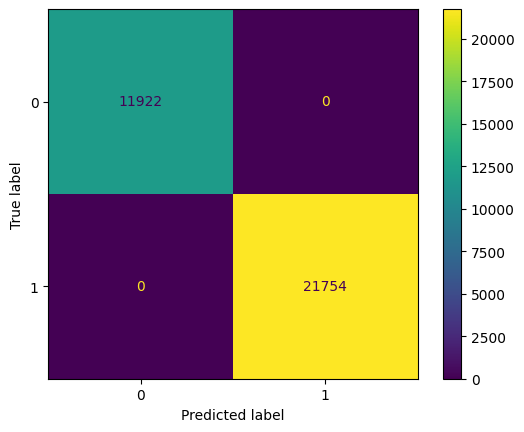

In [23]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [ ]:
# смотрим метрики Presision и Recall. Они идеальные.
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11922
           1       1.00      1.00      1.00     21754

    accuracy                           1.00     33676
   macro avg       1.00      1.00      1.00     33676
weighted avg       1.00      1.00      1.00     33676



In [25]:
roc_auc_score(y_test, y_pred)

1.0

In [26]:
precision_score(y_test, y_pred)

1.0

In [27]:
recall_score(y_test, y_pred)

1.0

посмотрим на важность признаков

In [28]:
model.feature_importances_

array([6.14322322e-16, 3.84282846e-15, 0.00000000e+00, 7.25829303e-19,
       1.87175307e-16, 1.71686956e-13, 1.08466951e-13, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 1.00000000e+00])

In [29]:
X.columns

Index(['sum_amount', 'mean_amount', 'count_transactions_completed',
       'count_reccurent_transactions', 'mean_date_diff',
       'first_transaction_date', 'last_transaction_date',
       'count_transactions_cancelled', 'cancelled_percentage', 'has_reccure',
       'sex_f', 'sex_m', 'sex_unknown', 'calc__current_date_diff_coeff'],
      dtype='object')

In [30]:
pd.DataFrame(X.columns, model.feature_importances_)

,0
6.143223e-16,sum_amount
3.842828e-15,mean_amount
0.000000e+00,count_transactions_completed
7.258293e-19,count_reccurent_transactions
1.871753e-16,mean_date_diff
1.716870e-13,first_transaction_date
1.084670e-13,last_transaction_date
0.000000e+00,count_transactions_cancelled
0.000000e+00,cancelled_percentage
0.000000e+00,has_reccure


Видим, что часть признаков можно исключить, они не играют никакой роли в нашей модели. Однако модель машинного обучения отрабатывает достаточно быстро, плюс в данном проекте предполагается использовать ее совместно с системой AW, где эти признаки могут понадобится при построении дашборда. Поэтому для возможного дальнейшего удобства было принято решение, их оставить и не удалять из набора признаков.

**Загрузим модель в Mlflow**

In [31]:
experiment_id = session.mlflow.setup_experiment('donor_churn__gar_line')

with session.mlflow.start_run(experiment_id=experiment_id):
    model.fit(X_train, y_train)
    
    # Предсказания и оценка метрики
    predictions = model.predict(X_test)
    roc_auc = roc_auc_score(y_test, predictions)
    presision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    
# Логируем метрики
    session.mlflow.log_metrics({'roc_auc': roc_auc, 'precision': presision, 'recall': recall})
    
# Логируем модель
    session.mlflow.sklearn.log_model(model, 'model', registered_model_name='donor_churn__gar_line')

Registered model 'donor_churn__gar_line' already exists. Creating a new version of this model...
2024/12/10 19:29:28 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: donor_churn__gar_line, version 17
Created version '17' of model 'donor_churn__gar_line'.
